In [9]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [10]:
load_dotenv()  # Load environment variables from .env file


True

In [11]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0)

In [12]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [13]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [14]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [15]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [16]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '**Blog Title:**  \n*The Rise of AI in India: Drivers, Impact, Challenges & the Road Ahead*\n\n---\n\n## 1. Introduction  \n- **Hook:** A striking statistic or anecdote (e.g., “India is projected to host 20‑30\u202f% of the world’s AI talent by 2030”).  \n- **Why it matters:** Briefly explain AI’s global significance and why India’s trajectory is a game‑changer for the economy, society, and the tech ecosystem.  \n- **Thesis statement:** Outline the blog’s purpose – to map the forces propelling AI in India, showcase real‑world impact, discuss hurdles, and envision the future.\n\n---\n\n## 2. Historical Context – From Early Adoption to a Full‑Blown AI Boom  \n| Period | Milestones | Key Players |\n|--------|------------|-------------|\n| **1990‑2005** | First AI research labs in IITs & ISI; early NLP & expert systems | IIT Madras, IIT Bombay, ISI Kolkata |\n| **2006‑2014** | Emergence of data‑centric research; start‑up incubators | NASSCOM, IIT

In [17]:
print(final_state['outline'])

**Blog Title:**  
*The Rise of AI in India: Drivers, Impact, Challenges & the Road Ahead*

---

## 1. Introduction  
- **Hook:** A striking statistic or anecdote (e.g., “India is projected to host 20‑30 % of the world’s AI talent by 2030”).  
- **Why it matters:** Briefly explain AI’s global significance and why India’s trajectory is a game‑changer for the economy, society, and the tech ecosystem.  
- **Thesis statement:** Outline the blog’s purpose – to map the forces propelling AI in India, showcase real‑world impact, discuss hurdles, and envision the future.

---

## 2. Historical Context – From Early Adoption to a Full‑Blown AI Boom  
| Period | Milestones | Key Players |
|--------|------------|-------------|
| **1990‑2005** | First AI research labs in IITs & ISI; early NLP & expert systems | IIT Madras, IIT Bombay, ISI Kolkata |
| **2006‑2014** | Emergence of data‑centric research; start‑up incubators | NASSCOM, IIT‑based incubators |
| **2015‑2020** | Deep learning wave; launch o

In [18]:
print(final_state['content'])

**Blog Title**  
*The Rise of AI in India: Drivers, Impact, Challenges & the Road Ahead*  

---

## 1. Introduction  

**Hook:** *“India is projected to host 20‑30 % of the world’s AI talent by 2030, and its AI‑driven GDP contribution could top **$500 billion** by the mid‑2030s.”*  

Artificial Intelligence is no longer a futuristic buzz‑word; it is reshaping economies, societies, and everyday life across the globe. For a country of 1.4 billion people, a youthful, English‑proficient workforce, and a rapidly digitising society, the AI story is a **game‑changer**.  

**Thesis statement:** This post maps the forces propelling AI in India, showcases real‑world impact across sectors, dissects the hurdles that still loom, and sketches a forward‑looking roadmap for policymakers, entrepreneurs, and professionals who want to ride the wave.

---

## 2. Historical Context – From Early Adoption to a Full‑Blown AI Boom  

| Period | Milestones | Key Players |
|--------|------------|-------------|
|

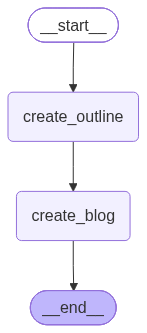

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())